In [1]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\bhavy\anaconda3\python.exe
3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]


In [40]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../data/bengaluru_airbnb.csv")

In [4]:
df.head()

,Country,Location,Airbnb_ListingID,Scrape_Date,Lat,Lng,MapMarkerType,City,ListingTitle,Bathrooms,...,OutlierPrice_PerBedroom,OutlierPrice_PerGuest,AvailableOverThanTwoWeeks,AvailableOver30Days,AvailableOver90Days,AvailableOver180Days,AvailableMoreThan30Days,AvailableMoreThan90Days,AvailableMoreThan180Days,RecordInserted
0,India,Bengaluru,1.015868e+18,2026-04-15 12:00:40,12.89139,77.59057,APPROX,Bengaluru,Premium 1 Bedroom flat@Bangalore,1.0,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2026-04-15 12:00:40.000000
1,India,Bengaluru,1.109830e+18,2026-04-15 12:24:29,12.80949,77.67486,APPROX,Bommasandra Area,2 BHK Apt W AC & King bed @ Narayana Hrudayalaya,2.0,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2026-04-15 12:24:29.000000
2,India,Bengaluru,1.110669e+18,2026-04-15 07:57:27,12.86710,77.58320,EXACT,Bengaluru,Private 1BHK Non-AC @Fortale Living @Christ Uni,1.0,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2026-04-15 07:57:27.000000
3,India,Bengaluru,1.110732e+18,2026-04-15 07:56:56,12.86720,77.58320,EXACT,Bengaluru,Roof-top Studio+Kitchen+Terrace (Solo) @ JP Nagar,1.0,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2026-04-15 07:56:56.000000
4,India,Bengaluru,1.213040e+18,2026-04-15 12:39:00,12.80320,77.67400,EXACT,Bommasandra Area,2BHK flat kitchen backup wifi- D - 3rd floor,2.0,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2026-04-15 12:39:00.000000


In [5]:
df.shape

(6002, 68)

In [6]:
df.columns.tolist() 
# This will give us complete list of column names

['Country',
 'Location',
 'Airbnb_ListingID',
 'Scrape_Date',
 'Lat',
 'Lng',
 'MapMarkerType',
 'City',
 'ListingTitle',
 'Bathrooms',
 'Bedrooms',
 'Beds',
 'PersonCapacity',
 'is_NewListing',
 'PictureCount',
 'is_GuestFavourite',
 'Host_ID',
 'Host_FirstName',
 'Host_isSuperhost',
 'Host_MultipleListings',
 'Host_MultipleListingsGlobal',
 'RoomType',
 'RoomType_Clean',
 'SpaceType',
 'SpaceType_Clean',
 'RoomAndPropertyType',
 'IsHomeOrServicedApartment',
 'ReviewCount',
 'StarRating',
 'RatingPct_5star',
 'RatingPct_4star',
 'RatingPct_3star',
 'RatingPct_2star',
 'RatingPct_1star',
 'LocationRating',
 'CleanlinessRating',
 'ValueRating',
 'AccuracyRating',
 'CheckinRating',
 'CommunicationRating',
 'VisibleReviewCount',
 'IsLowReviewScore',
 'NoReviewsNotNew',
 'Road',
 'Neighbourhood',
 'Suburb',
 'AddressCity',
 'StateDistrict',
 'Postcode',
 'IndexInSearchEngines',
 'BasicNightPrice_CheckIn',
 'BasicNightPrice_CheckOut',
 'Currency',
 'PrimaryPriceString',
 'BasicNightPrice',


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6002 entries, 0 to 6001
Data columns (total 68 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      6001 non-null   str    
 1   Location                     6000 non-null   str    
 2   Airbnb_ListingID             6000 non-null   float64
 3   Scrape_Date                  6000 non-null   str    
 4   Lat                          6000 non-null   float64
 5   Lng                          6000 non-null   float64
 6   MapMarkerType                5999 non-null   str    
 7   City                         6000 non-null   str    
 8   ListingTitle                 6000 non-null   str    
 9   Bathrooms                    5942 non-null   float64
 10  Bedrooms                     5902 non-null   float64
 11  Beds                         5997 non-null   float64
 12  PersonCapacity               6000 non-null   float64
 13  is_NewListing                

In [8]:
df.isnull().sum()
# this will give us exact no. of missing values in 68 columns

Country                     1
Location                    2
Airbnb_ListingID            2
Scrape_Date                 2
Lat                         2
                           ..
AvailableOver180Days        2
AvailableMoreThan30Days     2
AvailableMoreThan90Days     2
AvailableMoreThan180Days    2
RecordInserted              2
Length: 68, dtype: int64

In [9]:
df.isnull().sum()[df.isnull().sum() > 0]
# this will show us only the columns that actually need attention in removing null values

Country                     1
Location                    2
Airbnb_ListingID            2
Scrape_Date                 2
Lat                         2
                           ..
AvailableOver180Days        2
AvailableMoreThan30Days     2
AvailableMoreThan90Days     2
AvailableMoreThan180Days    2
RecordInserted              2
Length: 68, dtype: int64

In [10]:
df.describe()

,Airbnb_ListingID,Lat,Lng,Bathrooms,Bedrooms,Beds,PersonCapacity,PictureCount,Host_ID,Host_MultipleListings,...,Taxes_USD,OutlierPrice_PerBedroom,OutlierPrice_PerGuest,AvailableOverThanTwoWeeks,AvailableOver30Days,AvailableOver90Days,AvailableOver180Days,AvailableMoreThan30Days,AvailableMoreThan90Days,AvailableMoreThan180Days
count,6.000000e+03,6000.000000,6000.000000,5942.000000,5902.000000,5997.000000,6000.000000,6000.000000,6.000000e+03,6000.000000,...,5939.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.00000
mean,1.168158e+18,12.962609,77.631887,1.627651,1.739072,1.739370,3.684333,23.799167,8.300554e+14,0.843500,...,18.920796,0.013500,0.020500,0.997833,0.996000,0.943000,0.881833,0.994167,0.941000,0.87250
std,5.115788e+17,0.081458,0.055238,1.930907,2.457439,2.452675,2.694605,21.232058,3.711501e+16,0.363359,...,67.557060,0.115412,0.141715,0.046501,0.063124,0.231862,0.322832,0.076160,0.235644,0.33356
min,4.945120e+05,12.800650,77.403510,0.000000,1.000000,1.000000,1.000000,1.000000,8.632200e+04,0.000000,...,1.170000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,9.836965e+17,12.905720,77.602812,1.000000,1.000000,1.000000,2.000000,12.000000,1.637141e+08,1.000000,...,4.160000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000
50%,1.360904e+18,12.955494,77.630861,1.000000,1.000000,1.000000,3.000000,19.000000,4.201182e+08,1.000000,...,6.050000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000
75%,1.550590e+18,13.023000,77.659800,2.000000,2.000000,2.000000,4.000000,30.000000,5.935020e+08,1.000000,...,9.930000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000
max,1.663648e+18,13.202706,77.753650,50.000000,50.000000,50.000000,16.000000,600.000000,1.661096e+18,1.000000,...,3389.390000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [11]:
df.dtypes.value_counts()

float64    42
str        22
object      4
Name: count, dtype: int64

In [12]:
df.isnull().sum().sort_values(ascending=False)

Neighbourhood               3033
Road                        2945
RatingPct_4star             2554
RatingPct_1star             2554
RatingPct_2star             2554
                            ... 
AvailableOver180Days           2
AvailableMoreThan180Days       2
AvailableMoreThan90Days        2
RecordInserted                 2
Country                        1
Length: 68, dtype: int64

In [13]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percent': missing_percent
}).sort_values('Missing_Percent', ascending=False)

,Missing_Count,Missing_Percent
Neighbourhood,3033,50.533156
Road,2945,49.066978
RatingPct_4star,2554,42.552483
RatingPct_1star,2554,42.552483
RatingPct_2star,2554,42.552483
...,...,...
AvailableOver180Days,2,0.033322
AvailableMoreThan180Days,2,0.033322
AvailableMoreThan90Days,2,0.033322
RecordInserted,2,0.033322


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.nunique()
# df.unique() shows the no. of unique values in each column

Country                        2
Location                       1
Airbnb_ListingID            6000
Scrape_Date                 6000
Lat                         4830
                            ... 
AvailableOver180Days           2
AvailableMoreThan30Days        2
AvailableMoreThan90Days        2
AvailableMoreThan180Days       2
RecordInserted              6000
Length: 68, dtype: int64

In [16]:
df['RoomType'].value_counts()

RoomType
Entire home/flat    4219
Private room        1743
Shared room           38
Name: count, dtype: int64

In [17]:
df['City'].value_counts()

City
Bengaluru             5656
Bommasandra Area       171
Rajanukunte             18
Haralur                 18
Anagalapura             11
                      ... 
WJ2Q+7Q8 Bengaluru       1
Hoskote                  1
Banjarapalya             1
Hongasandra              1
Doddaballapura           1
Name: count, Length: 71, dtype: int64

In [18]:
df.isnull().sum().sort_values(ascending=False).head(10)
# this will simply show the 10 columns with most missing values

Neighbourhood          3033
Road                   2945
RatingPct_4star        2554
RatingPct_1star        2554
RatingPct_2star        2554
RatingPct_5star        2554
RatingPct_3star        2554
CommunicationRating    1607
ValueRating            1607
CheckinRating          1607
dtype: int64

In [19]:
df[['RoomType', 'City', 'Bedrooms', 'Bathrooms', 'PersonCapacity', 'BasicNightPrice']].head()

,RoomType,City,Bedrooms,Bathrooms,PersonCapacity,BasicNightPrice
0,Entire home/flat,Bengaluru,1.0,1.0,2.0,2337.0
1,Private room,Bommasandra Area,2.0,2.0,5.0,3120.0
2,Entire home/flat,Bengaluru,1.0,1.0,3.0,2560.0
3,Entire home/flat,Bengaluru,1.0,1.0,2.0,1492.0
4,Entire home/flat,Bommasandra Area,2.0,2.0,6.0,2546.0


In [20]:
df[['RoomType', 'City', 'Bedrooms', 'Bathrooms', 'PersonCapacity', 'BasicNightPrice']].isnull().sum()

RoomType             2
City                 2
Bedrooms           100
Bathrooms           60
PersonCapacity       2
BasicNightPrice     16
dtype: int64

In [21]:
df['RoomType'] = df['RoomType'].fillna(df['RoomType'].mode()[0])
df['City'] = df['City'].fillna(df['City'].mode()[0])
df['Bedrooms'] = df['Bedrooms'].fillna(df['Bedrooms'].median())
df['Bathrooms'] = df['Bathrooms'].fillna(df['Bathrooms'].median())
df['PersonCapacity'] = df['PersonCapacity'].fillna(df['PersonCapacity'].median())
df['BasicNightPrice'] = df['BasicNightPrice'].fillna(df['BasicNightPrice'].median())

In [22]:
df[['RoomType', 'City', 'Bedrooms', 'Bathrooms', 'PersonCapacity', 'BasicNightPrice']].isnull().sum()

RoomType           0
City               0
Bedrooms           0
Bathrooms          0
PersonCapacity     0
BasicNightPrice    0
dtype: int64

In [23]:
print("Min Price:",df['BasicNightPrice'].min())
print("Max Price:",df['BasicNightPrice'].max())
print("Average Price:",df['BasicNightPrice'].mean())
print("Median Price:",df['BasicNightPrice'].median())

Min Price: 438.0
Max Price: 350400.0
Average Price: 4093.642452515828
Median Price: 2598.5


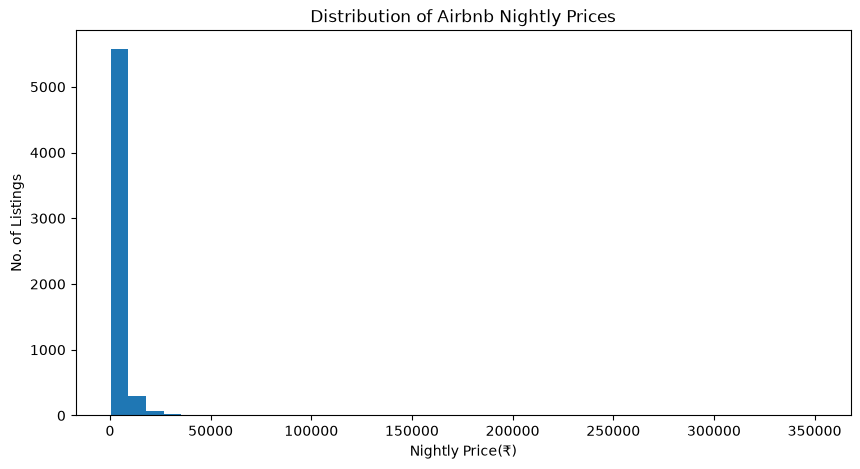

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.hist(df['BasicNightPrice'],bins=40)
plt.title('Distribution of Airbnb Nightly Prices')
plt.xlabel('Nightly Price(₹)')
plt.ylabel('No. of Listings')
plt.show()

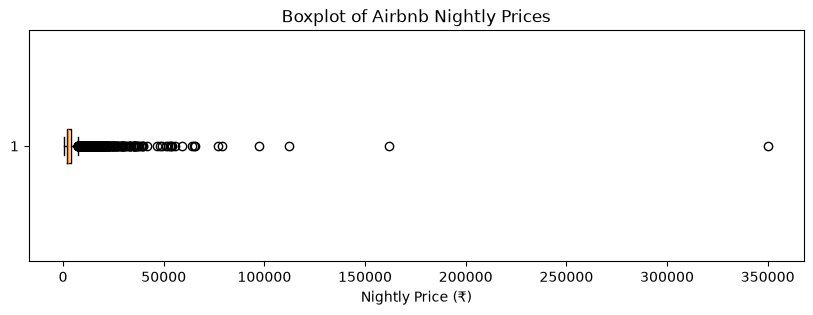

In [25]:
plt.figure(figsize=(10, 3))
plt.boxplot(df['BasicNightPrice'],orientation='horizontal')
plt.title('Boxplot of Airbnb Nightly Prices')
plt.xlabel('Nightly Price (₹)')
plt.show()

In [26]:
Q1 = df['BasicNightPrice'].quantile(0.25)
Q3 = df['BasicNightPrice'].quantile(0.75)
iqr = Q3-Q1
lf = Q1 - 1.5 * iqr
uf = Q3 + 1.5 * iqr
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", iqr)
print("Lower Fence (LF):",lf)
print("Upper Fence (UF):",uf)
outliers = df[
    (df['BasicNightPrice']<lf) | (df['BasicNightPrice']>uf)]
print("No. of potential outliers:",len(outliers))
print(
    "% of potential outliers:",(len(outliers)/len(df))*100)

Q1: 1776.0
Q3: 4064.0
IQR: 2288.0
Lower Fence (LF): -1656.0
Upper Fence (UF): 7496.0
No. of potential outliers: 590
% of potential outliers: 9.830056647784073


In [27]:
outliers[
    [
        'RoomType',
        'City',
        'Bedrooms',
        'Bathrooms',
        'PersonCapacity',
        'BasicNightPrice'
    ]
    ].sort_values(
        by='BasicNightPrice',
        ascending=False
    ).head(20)

,RoomType,City,Bedrooms,Bathrooms,PersonCapacity,BasicNightPrice
4338,Entire home/flat,Bengaluru,5.0,4.5,15.0,350400.0
1020,Entire home/flat,Bengaluru,1.0,1.0,2.0,162018.0
5945,Private room,Bengaluru,1.0,1.5,1.0,112333.0
3751,Entire home/flat,Bengaluru,4.0,6.0,8.0,97221.0
2727,Private room,Bengaluru,10.0,10.0,16.0,79052.0
3317,Private room,Bengaluru,40.0,41.0,16.0,76800.0
4892,Entire home/flat,Bagalur,5.0,6.0,15.0,65487.0
5943,Entire home/flat,Bengaluru,20.0,28.0,16.0,65190.0
830,Private room,Bengaluru,22.0,22.0,16.0,63839.0
4454,Private room,Bengaluru,1.0,1.0,4.0,58920.0


In [28]:
outliers['BasicNightPrice'].describe()

count       590.000000
mean      16220.540678
std       18693.848162
min        7499.000000
25%        8908.500000
50%       12150.000000
75%       16805.000000
max      350400.000000
Name: BasicNightPrice, dtype: float64

In [29]:
print("Bedrooms>10:",(df['Bedrooms']>10).sum())
print("Bathrooms>10:",(df['Bathrooms']>10).sum())
print("Beds>10:",(df['Beds']>10).sum())
print("PersonCapacity>16:",(df['PersonCapacity']>16).sum())

Bedrooms>10: 50
Bathrooms>10: 30
Beds>10: 51
PersonCapacity>16: 0


In [30]:
extreme_properties = df[
    (df['Bedrooms'] > 10) |
    (df['Bathrooms'] > 10) |
    (df['Beds'] > 10)
]

print("Extreme property records:", len(extreme_properties))

Extreme property records: 56


In [31]:
extreme_properties[
    [
        'RoomType',
        'City',
        'Bedrooms',
        'Bathrooms',
        'Beds',
        'PersonCapacity',
        'BasicNightPrice'
    ]
].sort_values(
    by='BasicNightPrice',
    ascending=False
)

,RoomType,City,Bedrooms,Bathrooms,Beds,PersonCapacity,BasicNightPrice
3317,Private room,Bengaluru,40.0,41.0,40.0,16.0,76800.0
5943,Entire home/flat,Bengaluru,20.0,28.0,20.0,16.0,65190.0
830,Private room,Bengaluru,22.0,22.0,22.0,16.0,63839.0
2750,Private room,Bommasandra Area,24.0,25.0,24.0,16.0,53990.0
4342,Private room,Bengaluru,24.0,24.0,24.0,16.0,53792.0
4579,Entire home/flat,Bengaluru,16.0,17.0,16.0,16.0,52899.0
4053,Entire home/flat,Rajanukunte,7.0,12.0,7.0,16.0,52279.0
2682,Private room,Bengaluru,16.0,16.0,16.0,16.0,48909.0
3921,Private room,Bommasandra Area,24.0,25.0,24.0,16.0,48000.0
5345,Private room,Bangalore Rural,7.0,12.0,7.0,16.0,34900.0


In [32]:
extreme_properties[
    [
        'Bedrooms','Bathrooms','Beds','BasicNightPrice']].describe()

,Bedrooms,Bathrooms,Beds,BasicNightPrice
count,56.000000,56.000000,56.000000,56.000000
mean,21.535714,12.455357,21.785714,13643.750000
std,11.396912,13.152005,11.087609,20723.359016
min,1.000000,0.000000,5.000000,1065.000000
25%,13.750000,1.000000,14.000000,2000.000000
50%,20.000000,11.000000,20.000000,3066.500000
75%,25.000000,20.000000,25.000000,10652.250000
max,50.000000,50.000000,50.000000,76800.000000


In [33]:
print("Bedrooms = 50:", (df['Bedrooms'] == 50).sum())
print("Bathrooms = 50:", (df['Bathrooms'] == 50).sum())
print("Beds = 50:", (df['Beds'] == 50).sum())

Bedrooms = 50: 1
Bathrooms = 50: 1
Beds = 50: 1


In [34]:
for column in ['Bedrooms','Bathrooms','Beds']:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    LF = Q1 - 1.5 * IQR
    UF = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < LF) |
        (df[column] > UF)
    ).sum()

    print("\n", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Fence:", LF)
    print("Upper Fence:", UF)
    print("Potential Outliers:", outlier_count)


 Bedrooms
Q1: 1.0
Q3: 2.0
IQR: 1.0
Lower Fence: -0.5
Upper Fence: 3.5
Potential Outliers: 341

 Bathrooms
Q1: 1.0
Q3: 2.0
IQR: 1.0
Lower Fence: -0.5
Upper Fence: 3.5
Potential Outliers: 297

 Beds
Q1: 1.0
Q3: 2.0
IQR: 1.0
Lower Fence: -0.5
Upper Fence: 3.5
Potential Outliers: 350


In [35]:
df[['Bedrooms','Bathrooms','Beds','PersonCapacity']].describe()

,Bedrooms,Bathrooms,Beds,PersonCapacity
count,6002.000000,6002.000000,5997.000000,6002.000000
mean,1.726758,1.621376,1.739370,3.684105
std,2.438713,1.922244,2.452675,2.694185
min,1.000000,0.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000
50%,1.000000,1.000000,1.000000,3.000000
75%,2.000000,2.000000,2.000000,4.000000
max,50.000000,50.000000,50.000000,16.000000


In [36]:
print("Bedrooms:")
print(df['Bedrooms'].value_counts().sort_index().head(15))

print("\nBathrooms:")
print(df['Bathrooms'].value_counts().sort_index().head(15))

print("\nBeds:")
print(df['Beds'].value_counts().sort_index().head(15))

Bedrooms:
Bedrooms
1.0     3970
2.0     1308
3.0      383
4.0      164
5.0       63
6.0       22
7.0       13
8.0       11
9.0        3
10.0      15
11.0       2
12.0       3
13.0       3
14.0       3
15.0       1
Name: count, dtype: int64

Bathrooms:
Bathrooms
0.0      38
1.0    3878
1.5     161
2.0    1263
2.5      40
3.0     303
3.5      22
4.0     146
4.5      11
5.0      47
5.5       1
6.0      26
6.5       1
7.0      11
8.0      10
Name: count, dtype: int64

Beds:
Beds
1.0     3942
2.0     1320
3.0      385
4.0      168
5.0       63
6.0       23
7.0       13
8.0       12
9.0        3
10.0      17
11.0       2
12.0       3
13.0       3
14.0       3
15.0       2
Name: count, dtype: int64


In [37]:
print("Bedrooms > 10:", (df['Bedrooms'] > 10).sum())
print("Bathrooms > 10:", (df['Bathrooms'] > 10).sum())
print("Beds > 10:", (df['Beds'] > 10).sum())

Bedrooms > 10: 50
Bathrooms > 10: 30
Beds > 10: 51


In [38]:
# Create a separate dataset for modeling

df_model = df[
    (df['Bedrooms'] <= 10) &
    (df['Bathrooms'] <= 10) &
    (df['Beds'] <= 10)
].copy()

print("Original dataset shape:", df.shape)
print("Modeling dataset shape:", df_model.shape)
print("Records removed:", len(df) - len(df_model))

Original dataset shape: (6002, 68)
Modeling dataset shape: (5941, 68)
Records removed: 61


In [41]:
df_model['LogPrice'] = np.log1p(df_model['BasicNightPrice'])
print(df_model[['BasicNightPrice','LogPrice']].head())

   BasicNightPrice  LogPrice
0           2337.0  7.757051
1           3120.0  8.045909
2           2560.0  7.848153
3           1492.0  7.308543
4           2546.0  7.842671


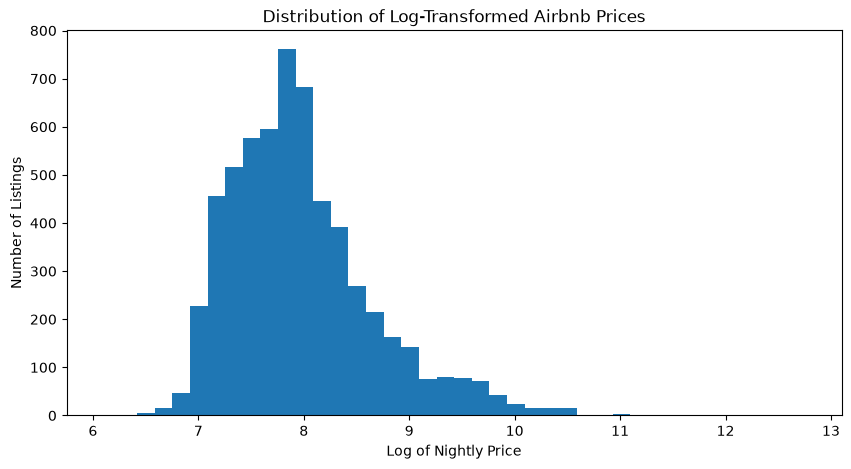

In [42]:
plt.figure(figsize=(10, 5))

plt.hist(df_model['LogPrice'], bins=40)

plt.title('Distribution of Log-Transformed Airbnb Prices')
plt.xlabel('Log of Nightly Price')
plt.ylabel('Number of Listings')

plt.show()

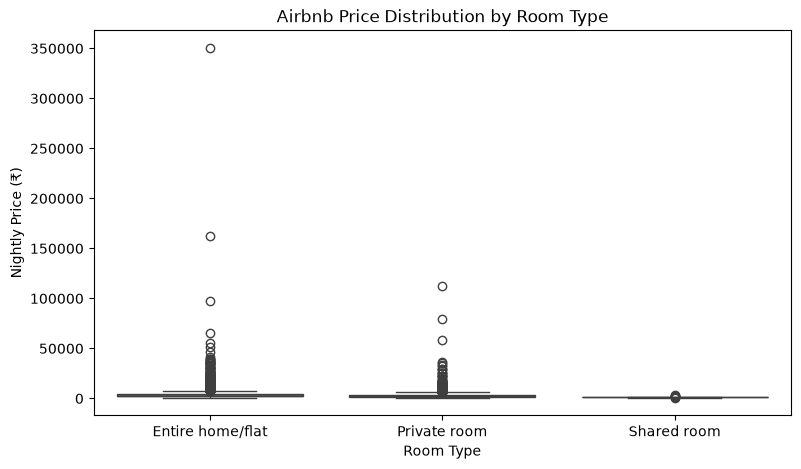

In [43]:
import seaborn as sns

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_model,
    x='RoomType',
    y='BasicNightPrice'
)

plt.title('Airbnb Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Nightly Price (₹)')

plt.show()

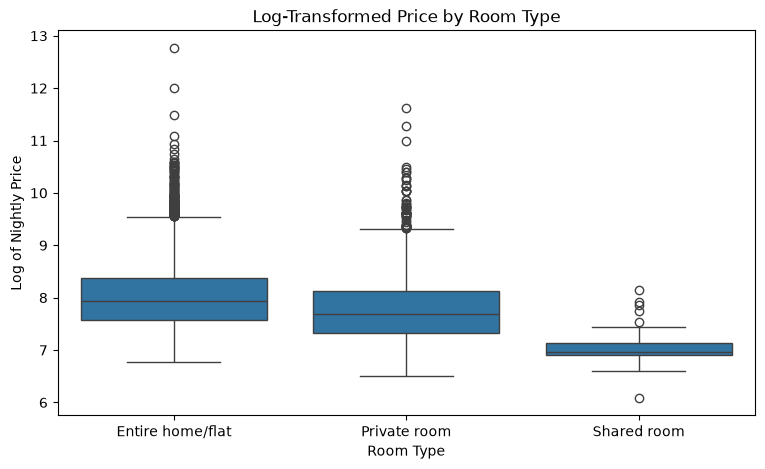

In [44]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_model,
    x='RoomType',
    y='LogPrice'
)

plt.title('Log-Transformed Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Log of Nightly Price')

plt.show()

In [45]:
room_type_summary = df_model.groupby('RoomType')['BasicNightPrice'].agg(
    ['count', 'mean', 'median']
).round(2)

room_type_summary

,count,mean,median
RoomType,,,
Entire home/flat,4209,4327.47,2786.0
Private room,1694,3264.62,2178.5
Shared room,38,1274.87,1051.0


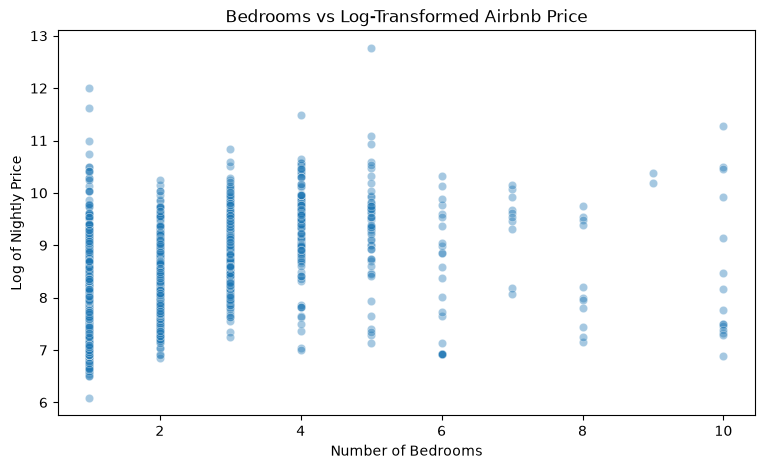

In [46]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df_model,
    x='Bedrooms',
    y='LogPrice',
    alpha=0.4
)

plt.title('Bedrooms vs Log-Transformed Airbnb Price')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Log of Nightly Price')

plt.show()

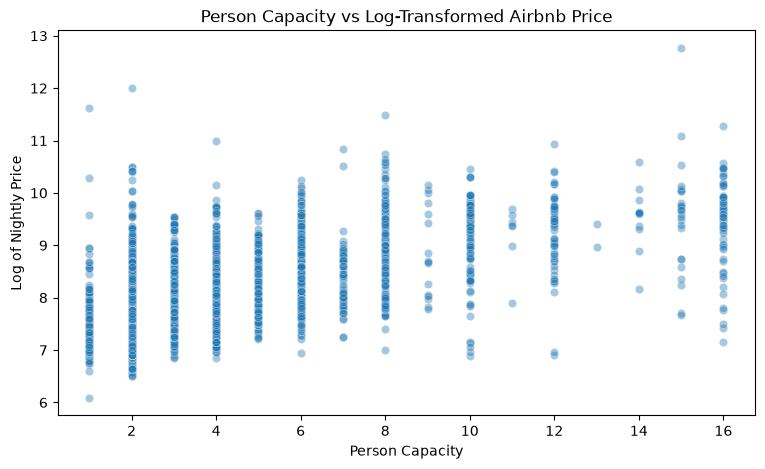

In [47]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df_model,
    x='PersonCapacity',
    y='LogPrice',
    alpha=0.4
)

plt.title('Person Capacity vs Log-Transformed Airbnb Price')
plt.xlabel('Person Capacity')
plt.ylabel('Log of Nightly Price')

plt.show()

In [48]:
# Correlation with log-transformed price

numeric_features = [
    'Bedrooms',
    'Bathrooms',
    'Beds',
    'PersonCapacity',
    'BasicNightPrice',
    'LogPrice'
]

correlation = df_model[numeric_features].corr()

correlation['LogPrice'].sort_values(ascending=False)

LogPrice           1.000000
BasicNightPrice    0.647194
PersonCapacity     0.590236
Bathrooms          0.550989
Bedrooms           0.546960
Beds               0.530339
Name: LogPrice, dtype: float64

In [49]:
# Features and target

features = [
    'RoomType',
    'City',
    'Bedrooms',
    'Bathrooms',
    'Beds',
    'PersonCapacity'
]

X = df_model[features]
y = df_model['LogPrice']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5941, 6)
Target shape: (5941,)


In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ['RoomType', 'City']
numerical_features = [
    'Bedrooms',
    'Bathrooms',
    'Beds',
    'PersonCapacity'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

X_encoded = preprocessor.fit_transform(X)

print("Encoded feature shape:", X_encoded.shape)

Encoded feature shape: (5941, 77)


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4752, 6)
X_test: (1189, 6)
y_train: (4752,)
y_test: (1189,)


In [52]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (4752, 64)
Encoded testing shape: (1189, 64)


In [53]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_encoded,y_train)
print("Successfully!")

Successfully!


In [54]:
y_pred = model.predict(X_test_encoded)
print("First 10 Predicted Prices:")
print(y_pred[:10])
      

First 10 Predicted Prices:
[7.66175982 7.92843447 7.92843447 7.73659236 8.71093196 7.73659236
 7.73659236 7.73659236 8.94162198 7.73659236]


In [55]:
predicted_price =np.expm1(y_pred)
print("First 10 Prdicted Prices in Rs.:")
print(predicted_price[:10])

First 10 Prdicted Prices in Rs.:
[2124.49462959 2774.0789391  2774.0789391  2289.65335322 6067.89584242
 2289.65335322 2289.65335322 2289.65335322 7642.58472076 2289.65335322]


In [56]:
comparison = pd.DataFrame({
    'Actual Price':np.expm1(y_test),
    'Predicted Price:':predicted_price
})
print (comparison.head(10))

      Actual Price  Predicted Price:
5853        1980.0       2124.494630
1641        1637.0       2774.078939
3461        4500.0       2774.078939
2139        1455.0       2289.653353
2710        3009.0       6067.895842
2350        1853.0       2289.653353
4236        4555.0       2289.653353
4317        1719.0       2289.653353
2739        5800.0       7642.584721
5209        2918.0       2289.653353


In [58]:
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(np.exp(y_test),predicted_price)
mse = mean_squared_error(np.exp(y_test),predicted_price)
rmse = np.sqrt(mse)
r2=r2_score(np.exp(y_test),predicted_price)
print("Mean Absolute Error (MAE):",mae)
print("Mean Sqaured Error (MSE):",mse)
print("Root Mean Squared Error (MAE):",rmse)
print("R2 scor:",r2)

Mean Absolute Error (MAE): 1637.5902490661647
Mean Sqaured Error (MSE): 11725619.865508309
Root Mean Squared Error (MAE): 3424.269245475348
R2 scor: 0.30348005062505057


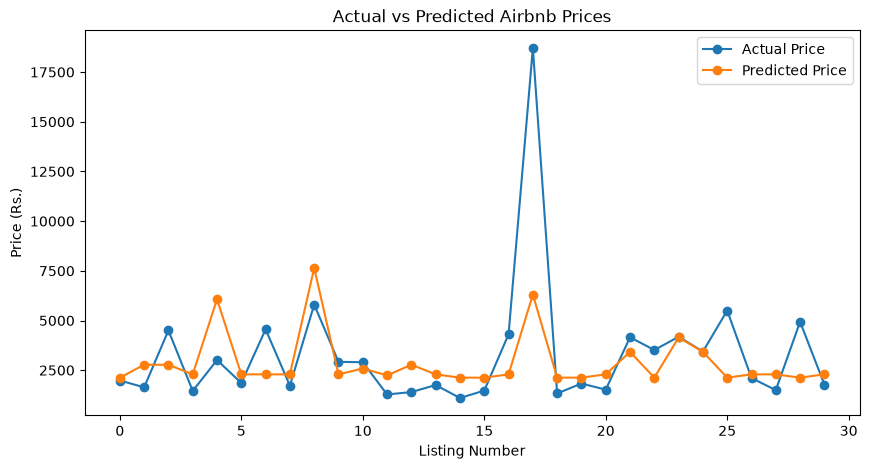

In [61]:
actual_price = np.exp(y_test.values[:30])

predicted_price_30 = predicted_price[:30]

plt.figure(figsize=(10, 5))

plt.plot(actual_price, marker='o', label='Actual Price')
plt.plot(predicted_price_30, marker='o', label='Predicted Price')

plt.xlabel("Listing Number")
plt.ylabel("Price (Rs.)")
plt.title("Actual vs Predicted Airbnb Prices")

plt.legend()
plt.show()

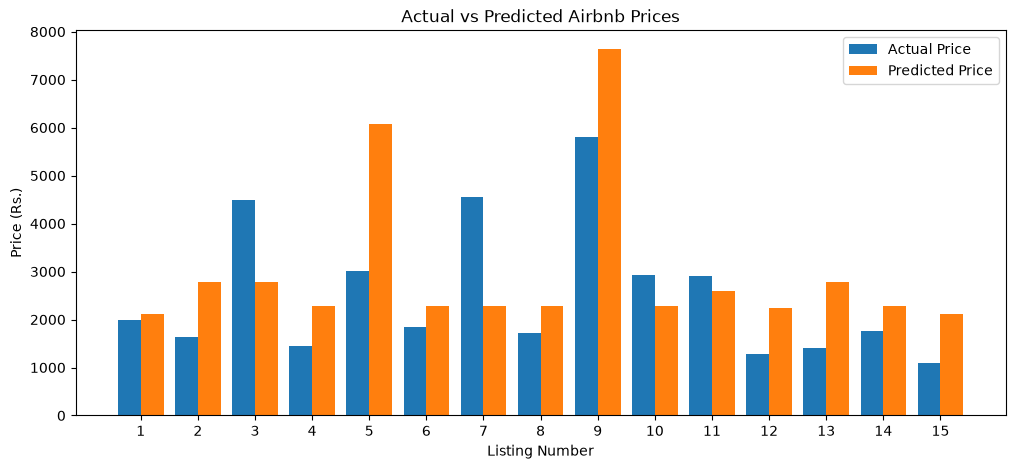

In [62]:
import numpy as np
import matplotlib.pyplot as plt

actual_price = np.exp(y_test)

x = np.arange(15)

plt.figure(figsize=(12, 5))

plt.bar(x - 0.2, actual_price[:15], width=0.4, label='Actual Price')
plt.bar(x + 0.2, predicted_price[:15], width=0.4, label='Predicted Price')

plt.xlabel("Listing Number")
plt.ylabel("Price (Rs.)")
plt.title("Actual vs Predicted Airbnb Prices")
plt.xticks(x, range(1, 16))
plt.legend()

plt.show()

In [63]:
price_diff = actual_price - predicted_price
print("First 10 Price Differences:")
print(price_diff[:10])

First 10 Price Differences:
5853    -143.494630
1641   -1136.078939
3461    1726.921061
2139    -833.653353
2710   -3057.895842
2350    -435.653353
4236    2266.346647
4317    -569.653353
2739   -1841.584721
5209     629.346647
Name: LogPrice, dtype: float64


In [70]:
def classifyPrice(diff):
    if diff>500:
        return "Possibly Overpriced"
    elif diff<-500:
        return "Possibly Underpriced"
    else:
        return "Fair Price"
opp = [classifyPrice(diff) for diff in price_diff]
print("First 10 Opportunity Result:")
print(opp[:10])

First 10 Opportunity Result:
['Fair Price', 'Possibly Underpriced', 'Possibly Overpriced', 'Possibly Underpriced', 'Possibly Underpriced', 'Fair Price', 'Possibly Overpriced', 'Possibly Underpriced', 'Possibly Underpriced', 'Possibly Overpriced']


In [71]:
opp_df = pd.DataFrame({
    'Actual Price':actual_price,
    'Prdicted Price':predicted_price,
    'Price Difference':price_diff,
    'Opportunity':opp
})
opp_df.head(10)

,Actual Price,Prdicted Price,Price Difference,Opportunity
5853,1981.0,2124.494630,-143.494630,Fair Price
1641,1638.0,2774.078939,-1136.078939,Possibly Underpriced
3461,4501.0,2774.078939,1726.921061,Possibly Overpriced
2139,1456.0,2289.653353,-833.653353,Possibly Underpriced
2710,3010.0,6067.895842,-3057.895842,Possibly Underpriced
2350,1854.0,2289.653353,-435.653353,Fair Price
4236,4556.0,2289.653353,2266.346647,Possibly Overpriced
4317,1720.0,2289.653353,-569.653353,Possibly Underpriced
2739,5801.0,7642.584721,-1841.584721,Possibly Underpriced
5209,2919.0,2289.653353,629.346647,Possibly Overpriced


In [72]:
oppCount = opp_df['Opportunity'].value_counts()

print("Opportunity Summary:")
print(oppCount)

Opportunity Summary:
Opportunity
Possibly Underpriced    417
Possibly Overpriced     393
Fair Price              379
Name: count, dtype: int64


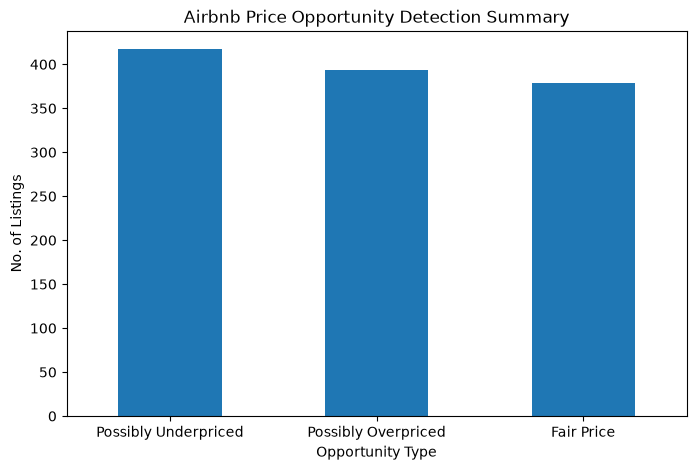

In [73]:
plt.figure(figsize=(8,5))
oppCount.plot(kind='bar')
plt.xlabel("Opportunity Type")
plt.ylabel("No. of Listings")
plt.title("Airbnb Price Opportunity Detection Summary")
plt.xticks(rotation=0)
plt.show()

In [75]:
import joblib
joblib.dump(model,"../models/airbnb_price_model.pkl")
joblib.dump(preprocessor,"../models/airbnb_preprocessor.pkl")
print("Model and preprocessor saved successfully")

Model and preprocessor saved successfully
